In [1]:
# Ensure the project root is on PYTHONPATH when running from notebooks/
from pathlib import Path
import sys
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))



# 01 - PID reference autotune and baseline run

In [2]:
import os, json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# Ensure local package import
import sys
sys.path.insert(0, str(Path('..').resolve()))

from hybrid_acdc.utils.io import load_yaml, load_json, save_json
from hybrid_acdc.cli.main import cmd_autotune


In [3]:
cfg_path = '../config/system.yaml'
out_dir = Path('../results/pid_ref')
out_dir.mkdir(parents=True, exist_ok=True)

# Run autotune (same as CLI)
import argparse
args = argparse.Namespace(config=cfg_path, out=str(out_dir), max_evals=48, verbose=True)
cmd_autotune(args)

pid_ref = load_json(out_dir/'pid_ref.json')
pid_ref


[PID autotune] eval 001/48: cost=2450186741.6882  (best=2450186741.6882)
[PID autotune] eval 005/48: cost=58181153.9483  (best=58181153.9483)
[PID autotune] eval 010/48: cost=929387928.5869  (best=58181153.9483)
[PID autotune] eval 015/48: cost=24077022488.2797  (best=58181153.9483)
[PID autotune] eval 020/48: cost=1705240108.8400  (best=58181153.9483)
[PID autotune] eval 025/48: cost=21017807865.0936  (best=58181153.9483)
[PID autotune] eval 030/48: cost=23203394400.7243  (best=58181153.9483)
[PID autotune] eval 035/48: cost=198503973.4611  (best=58181153.9483)
[PID autotune] eval 040/48: cost=14690408528.7593  (best=58181153.9483)
[PID autotune] eval 045/48: cost=23027205125.7717  (best=58181153.9483)
[PID autotune] eval 048/48: cost=205616173.9175  (best=58181153.9483)
Saved PID reference gains to: ..\results\pid_ref\pid_ref.json


{'vdc_kp': 10200.0,
 'vdc_ki': 61200.00000000001,
 'alpha': 0.5,
 'cost': 58181153.94834191}

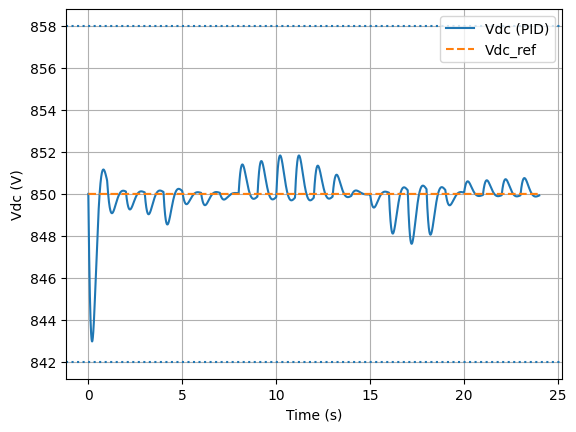

In [4]:
from hybrid_acdc.plant.avg_model import simulate_averaged
from hybrid_acdc.controllers.control_laws import OuterLoopConfig, PIDOuterController

cfg = load_yaml(cfg_path)
outer = OuterLoopConfig(vdc_nom=cfg['dc_bus']['vdc_nom'],
                        P_import_max=cfg['secondary']['P_import_max_kw']*1e3,
                        P_export_max=cfg['secondary']['P_export_max_kw']*1e3)

ctrl = PIDOuterController(kp=pid_ref['vdc_kp'], ki=pid_ref['vdc_ki'], alpha=pid_ref['alpha'], outer=outer)
sig = simulate_averaged(cfg, controller=ctrl, seed=cfg['sim']['seed'])

plt.figure()
plt.plot(sig.t, sig.vdc, label='Vdc (PID)')
plt.plot(sig.t, sig.vdc_ref, '--', label='Vdc_ref')
plt.axhline(cfg['dc_bus']['vdc_min'], linestyle=':')
plt.axhline(cfg['dc_bus']['vdc_max'], linestyle=':')
plt.xlabel('Time (s)')
plt.ylabel('Vdc (V)')
plt.legend()
plt.grid(True)
plt.show()
